<a href="https://colab.research.google.com/github/juliabonifaciio/1TIAPR-CP1-Python-JuliaBonifacio/blob/main/CP1_JuliaBonifacio_566673.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seção 1 — Instalação de dependências

Nesta etapa serão instaladas as bibliotecas usadas no trabalho. O projeto será executado no Google Colab.

In [ ]:
!pip -q install nltk spacy transformers torch scikit-learn wordcloud matplotlib pandas numpy tqdm gradio sentencepiece
!python -m spacy download pt_core_news_sm -q

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Instalação concluída.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 74.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Instalação concluída.


# Seção 2 — Download do corpus

Serão usadas exatamente três obras de Eça de Queirós em português. Os textos serão baixados diretamente do Project Gutenberg por código.

In [ ]:
import requests
import pandas as pd

obras = {
    "Os Maias": {
        "autor": "Eça de Queirós",
        "ano": 1888,
        "gutenberg_id": "40409",
        "url": "https://www.gutenberg.org/cache/epub/40409/pg40409.txt"
    },
    "O Crime do Padre Amaro": {
        "autor": "Eça de Queirós",
        "ano": 1875,
        "gutenberg_id": "31971",
        "url": "https://www.gutenberg.org/cache/epub/31971/pg31971.txt"
    },
    "O Primo Basílio": {
        "autor": "Eça de Queirós",
        "ano": 1878,
        "gutenberg_id": "42942",
        "url": "https://www.gutenberg.org/cache/epub/42942/pg42942.txt"
    }
}

textos = {}

for nome, dados in obras.items():
    resposta = requests.get(dados["url"], timeout=30)
    resposta.raise_for_status()
    resposta.encoding = "utf-8"
    textos[nome] = resposta.text

    print(nome, "baixado com sucesso.")

dados_corpus = []

for nome, texto in textos.items():
    dados_corpus.append({
        "Obra": nome,
        "Autor": obras[nome]["autor"],
        "Ano": obras[nome]["ano"],
        "Gutenberg ID": obras[nome]["gutenberg_id"],
        "Caracteres brutos": len(texto),
        "Palavras brutas": len(texto.split()),
        "Linhas": len(texto.splitlines())
    })

df_corpus = pd.DataFrame(dados_corpus)
display(df_corpus)

for nome, texto in textos.items():
    print("\n", nome)
    print("PRIMEIROS 500 CARACTERES")
    print(texto[:500])
    print("\nÚLTIMOS 500 CARACTERES")
    print(texto[-500:])

Os Maias baixado com sucesso.
O Crime do Padre Amaro baixado com sucesso.
O Primo Basílio baixado com sucesso.


,Obra,Autor,Ano,Gutenberg ID,Caracteres brutos,Palavras brutas,Linhas
0,Os Maias,Eça de Queirós,1888,40409,1338722,215373,27482
1,O Crime do Padre Amaro,Eça de Queirós,1875,31971,881844,141731,19170
2,O Primo Basílio,Eça de Queirós,1878,42942,768698,118522,19037



 Os Maias
PRIMEIROS 500 CARACTERES
The Project Gutenberg eBook of Os Maias: episodios da vida romantica
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located


ÚLTIMOS 500 CARACTERES
n
the U.S. unless a copyright notice is included. Thus, we do not
necessarily keep eBooks in compliance with any particular paper
edition.

Most people start at our website which has the main PG search
facility: www.gutenberg.org.

This website includes information about Project Gutenberg,
including how to make donations to the Project Gutenberg Literary
Archive Foundation, how to help produce our new eBooks, and how to
subscribe to our email 

# Seção 3 — Limpeza e normalização

A mesma função será aplicada às três obras. A limpeza segue os sete passos pedidos no trabalho.

In [ ]:
import re
import unicodedata

def limpar_texto(texto):
    inicio = re.search(r"\*\*\* START OF[^\n]*", texto, flags=re.IGNORECASE)
    fim = re.search(r"\*\*\* END OF[^\n]*", texto, flags=re.IGNORECASE)

    if inicio:
        texto = texto[inicio.end():]
    if fim:
        texto = texto[:fim.start()]

    texto = texto.encode("utf-8", "ignore").decode("utf-8")
    texto = unicodedata.normalize("NFC", texto)
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ\s]", " ", texto)

    linhas = []
    for linha in texto.splitlines():
        linha = re.sub(r"\s+", " ", linha).strip()
        if linha:
            linhas.append(linha)

    linhas_finais = []
    for linha in linhas:
        if len(linha.split()) >= 3:
            linhas_finais.append(linha)

    return "\n".join(linhas_finais)

textos_limpos = {}

for nome, texto in textos.items():
    textos_limpos[nome] = limpar_texto(texto)

for nome in textos:
    antes = len(textos[nome].split())
    depois = len(textos_limpos[nome].split())
    reducao = ((antes - depois) / antes) * 100

    print("\n", nome)
    print("Palavras antes:", antes)
    print("Palavras depois:", depois)
    print("Redução:", round(reducao, 2), "%")

    linhas_antes = textos[nome].splitlines()
    linhas_depois = textos_limpos[nome].splitlines()

    tabela_linhas = pd.DataFrame({
        "Antes": linhas_antes[:5],
        "Depois": linhas_depois[:5]
    })

    display(tabela_linhas)


 Os Maias
Palavras antes: 215373
Palavras depois: 220135
Redução: -2.21 %


,Antes,Depois
0,The Project Gutenberg eBook of Os Maias: episo...,nota de editor devido à existência de erros ti...
1,,texto foram tomadas várias decisões quanto à v...
2,This eBook is for the use of anyone anywhere i...,de dúvida a grafia foi mantida de acordo com o...
3,most other parts of the world at no cost and w...,deste livro encontrará a lista de erros corrig...
4,"whatsoever. You may copy it, give it away or r...",na versão original esta obra é uma compilação ...



 O Crime do Padre Amaro
Palavras antes: 141731
Palavras depois: 144310
Redução: -1.82 %


,Antes,Depois
0,The Project Gutenberg eBook of O crime do padr...,produced by rita farinha and the online distri...
1,,proofreading team at https www pgdp net this f...
2,This eBook is for the use of anyone anywhere i...,produced from images generously made available...
3,most other parts of the world at no cost and w...,library of portugal biblioteca nacional de por...
4,"whatsoever. You may copy it, give it away or r...",nota de editor devido à quantidade de erros ti...



 O Primo Basílio
Palavras antes: 118522
Palavras depois: 122406
Redução: -3.28 %


,Antes,Depois
0,The Project Gutenberg eBook of O Primo Bazilio...,nota de editor devido à existência de erros ti...
1,,texto foram tomadas várias decisões quanto à v...
2,This eBook is for the use of anyone anywhere i...,de dúvida a grafia foi mantida de acordo com o...
3,most other parts of the world at no cost and w...,deste livro encontrará a lista de erros corrig...
4,"whatsoever. You may copy it, give it away or r...",rita farinha junho


# Seção 4 — Tokenização, stop words e lematização

Os textos serão tokenizados com NLTK, terão as stop words em português removidas e depois serão lematizados com spaCy. A lematização será feita somente depois da remoção das stop words.

Lista de stop words:
['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'essa', 'essas', 'esse', 'esses', 'esta', 'estamos', 'estar', 'estas', 'estava', 'estavam', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéramos', 'estivéssemos', 'estou', 'está', 'estávamos', 'estão', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'forem', 'formos', 'fosse', 'fossem', 'fui', 'fôramos', 'fôssemos', 'haja', 'hajam', 'hajamos', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houveram', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houvermos', 'houverá', 'houverão', 'houveríamos', 'houvesse', 'houvessem', 'houvéramos', 'houvéssemos', 'há', 'hão',

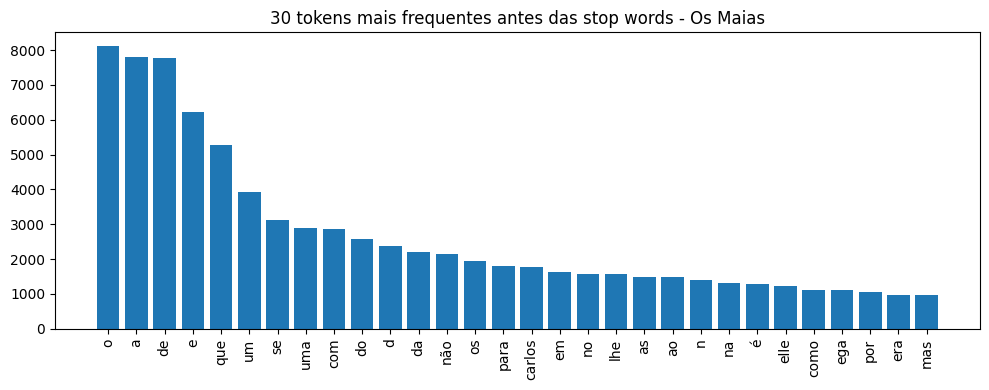

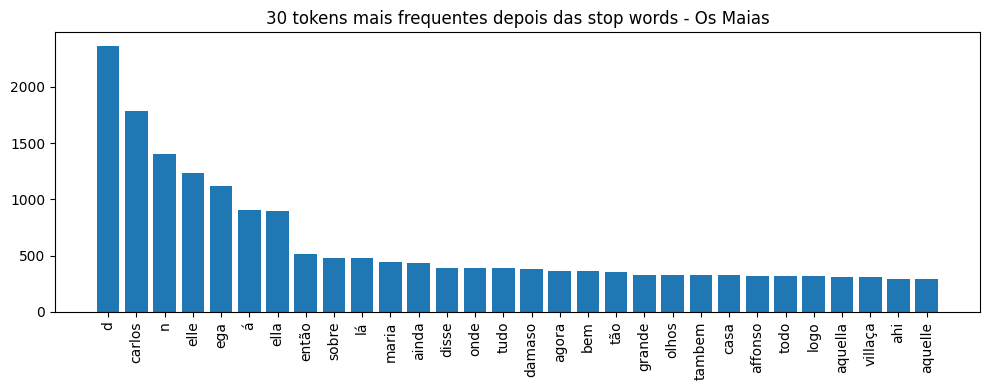


 Os Maias - 20 exemplos de token e lema


,Token,Lema
0,nota,nota
1,editor,editor
2,devido,devido
3,existência,existência
4,erros,erro
5,tipográficos,tipográfico
6,neste,em este
7,texto,texto
8,tomadas,tomar
9,várias,várias


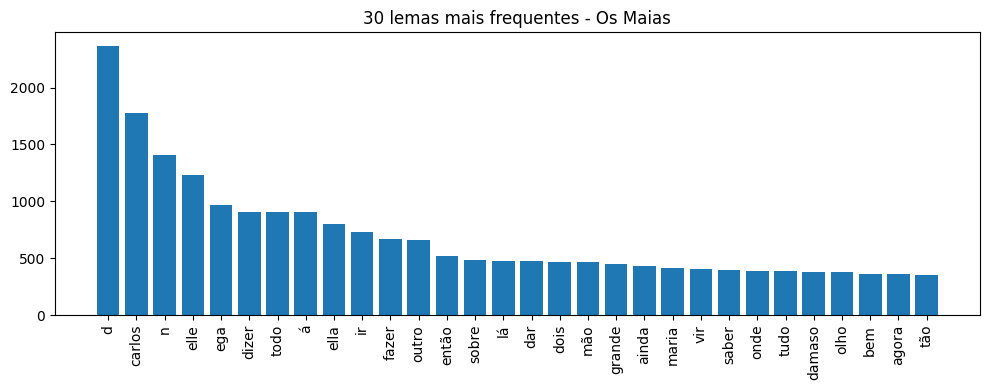

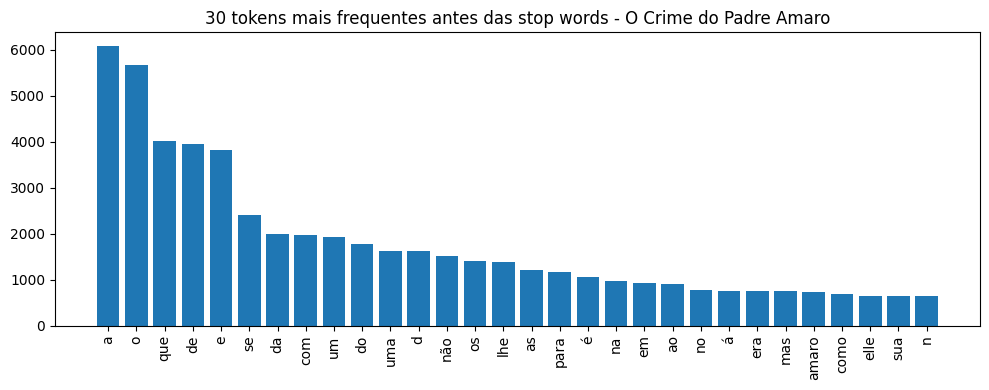

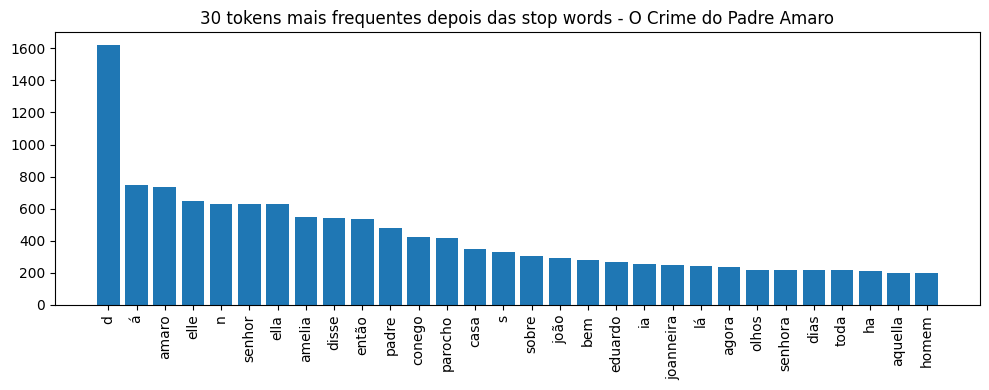


 O Crime do Padre Amaro - 20 exemplos de token e lema


,Token,Lema
0,produced,produced
1,by,by
2,rita,rito
3,farinha,farinha
4,and,and
5,the,the
6,online,onliner
7,distributed,distributed
8,proofreading,proofreading
9,team,team


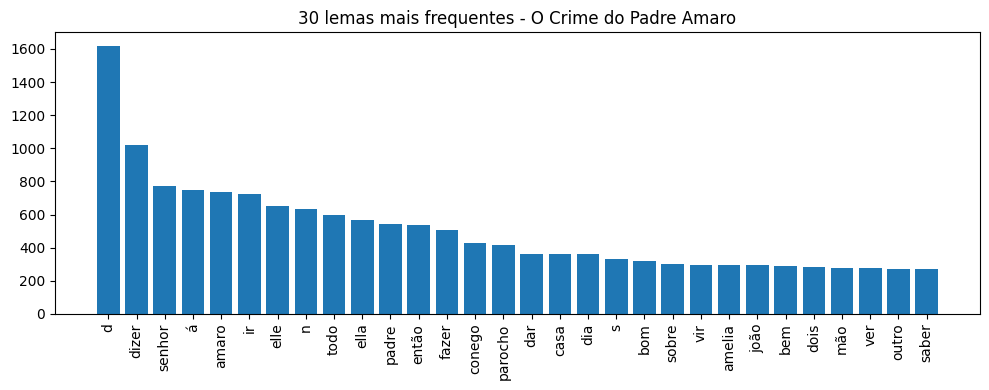

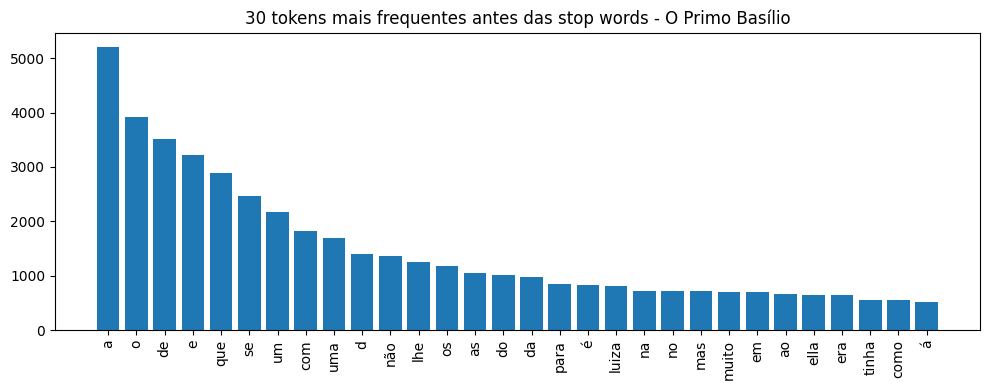

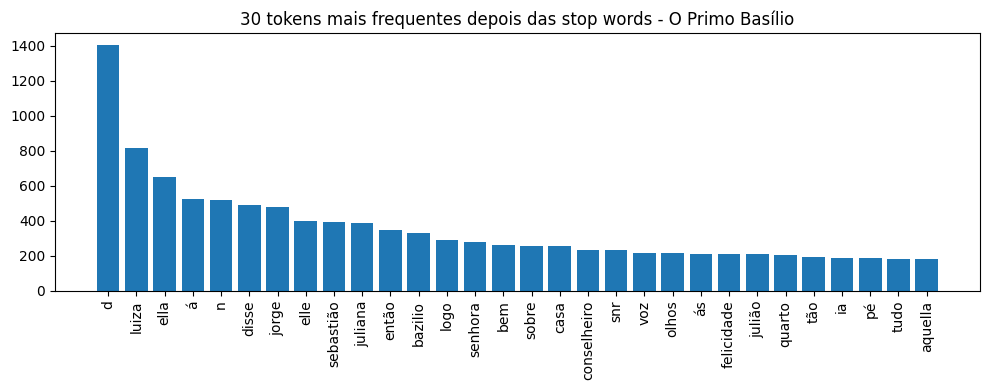


 O Primo Basílio - 20 exemplos de token e lema


,Token,Lema
0,nota,nota
1,editor,editor
2,devido,devido
3,existência,existência
4,erros,erro
5,tipográficos,tipográfico
6,neste,em este
7,texto,texto
8,tomadas,tomar
9,várias,várias


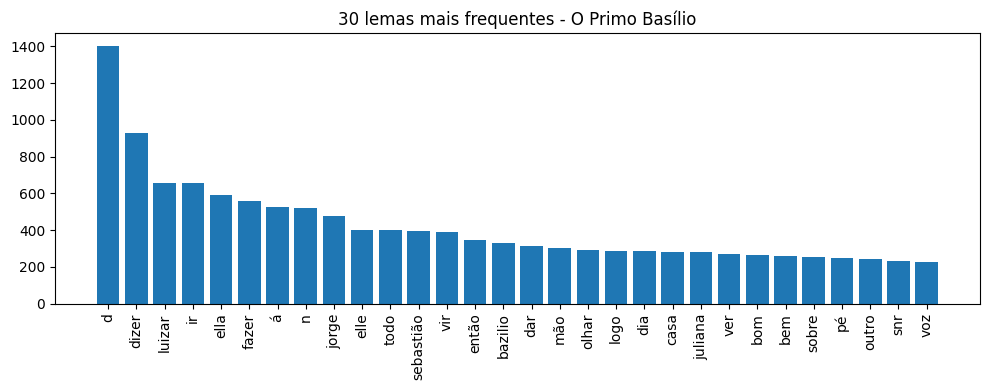


Seção 4 concluída.


In [ ]:
import nltk
import spacy
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

nlp = spacy.load("pt_core_news_sm")
stop_words = set(stopwords.words("portuguese"))

tokens = {}
tokens_sem_stopwords = {}
lemmas = {}

print("Lista de stop words:")
print(sorted(stop_words))

for nome, texto in textos_limpos.items():
    tokens[nome] = word_tokenize(texto, language="portuguese")

    tokens_sem_stopwords[nome] = [
        palavra for palavra in tokens[nome]
        if palavra.isalpha() and palavra not in stop_words
    ]

    doc = nlp(" ".join(tokens_sem_stopwords[nome]))

    lemmas[nome] = [
        token.lemma_.lower()
        for token in doc
        if token.lemma_.isalpha()
    ]

    frequencia_antes = Counter(tokens[nome]).most_common(30)
    frequencia_depois = Counter(tokens_sem_stopwords[nome]).most_common(30)
    frequencia_lemmas = Counter(lemmas[nome]).most_common(30)

    plt.figure(figsize=(10, 4))
    plt.bar([x[0] for x in frequencia_antes], [x[1] for x in frequencia_antes])
    plt.xticks(rotation=90)
    plt.title("30 tokens mais frequentes antes das stop words - " + nome)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar([x[0] for x in frequencia_depois], [x[1] for x in frequencia_depois])
    plt.xticks(rotation=90)
    plt.title("30 tokens mais frequentes depois das stop words - " + nome)
    plt.tight_layout()
    plt.show()

    exemplos = []
    doc_exemplo = nlp(" ".join(tokens_sem_stopwords[nome][:100]))

    for token in doc_exemplo:
        if token.text.isalpha():
            exemplos.append([token.text, token.lemma_])
        if len(exemplos) == 20:
            break

    print("\n", nome, "- 20 exemplos de token e lema")
    display(pd.DataFrame(exemplos, columns=["Token", "Lema"]))

    plt.figure(figsize=(10, 4))
    plt.bar([x[0] for x in frequencia_lemmas], [x[1] for x in frequencia_lemmas])
    plt.xticks(rotation=90)
    plt.title("30 lemas mais frequentes - " + nome)
    plt.tight_layout()
    plt.show()

print("\nSeção 4 concluída.")

# Seção 5 — EDA textual

Nesta etapa serão analisados o vocabulário, as nuvens de palavras, o tamanho das frases, uma tabela comparativa e os bigramas mais frequentes.


 Os Maias
Tokens únicos: 19855
Lemas únicos: 15357


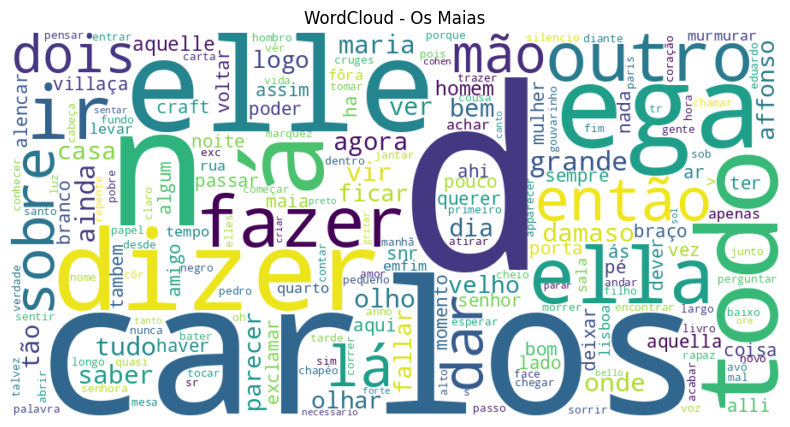


 O Crime do Padre Amaro
Tokens únicos: 15095
Lemas únicos: 11467


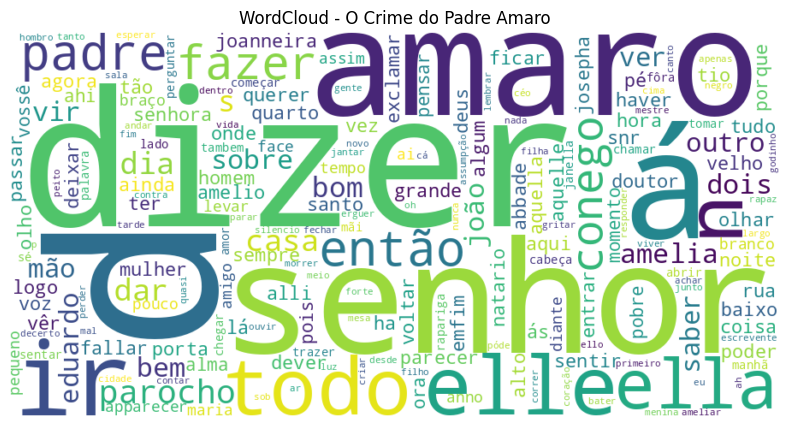


 O Primo Basílio
Tokens únicos: 13241
Lemas únicos: 10222


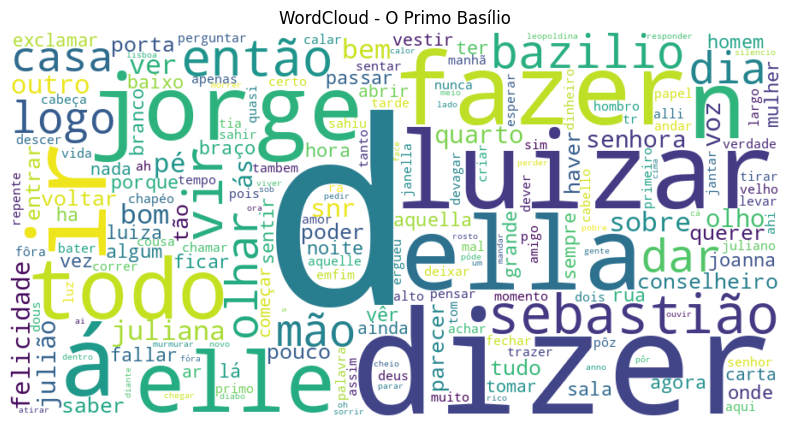

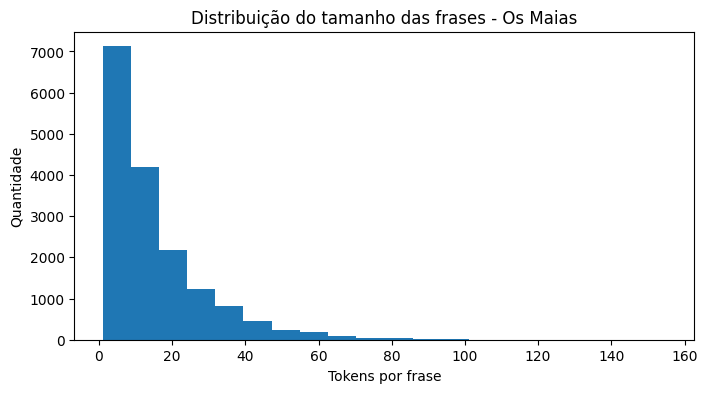

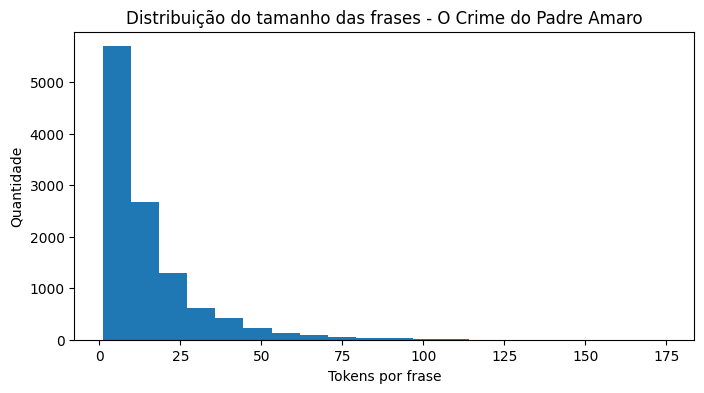

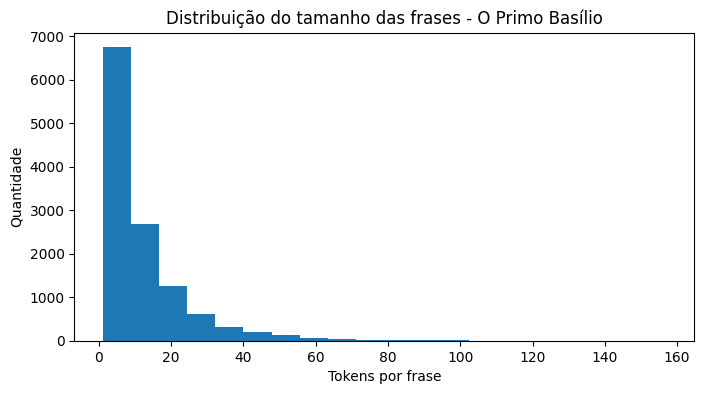

,Obra,Total de tokens,Lemas únicos,Frase mais longa,Frase mais curta
0,Os Maias,128398,15357,155,1
1,O Crime do Padre Amaro,82982,11467,175,1
2,O Primo Basílio,71259,10222,157,1


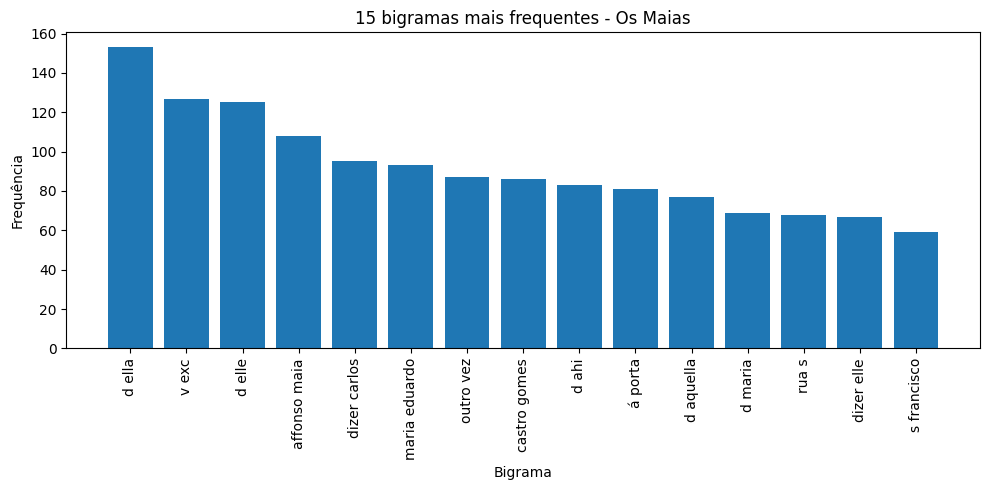

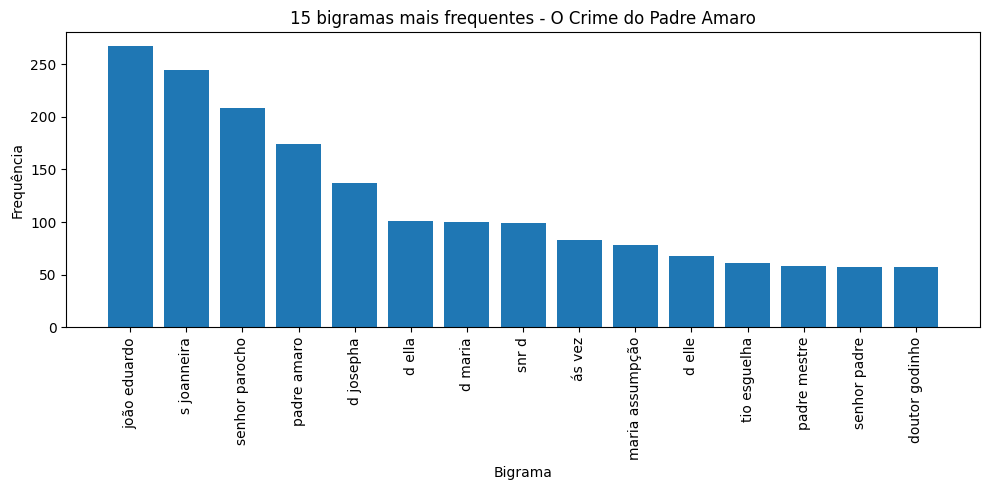

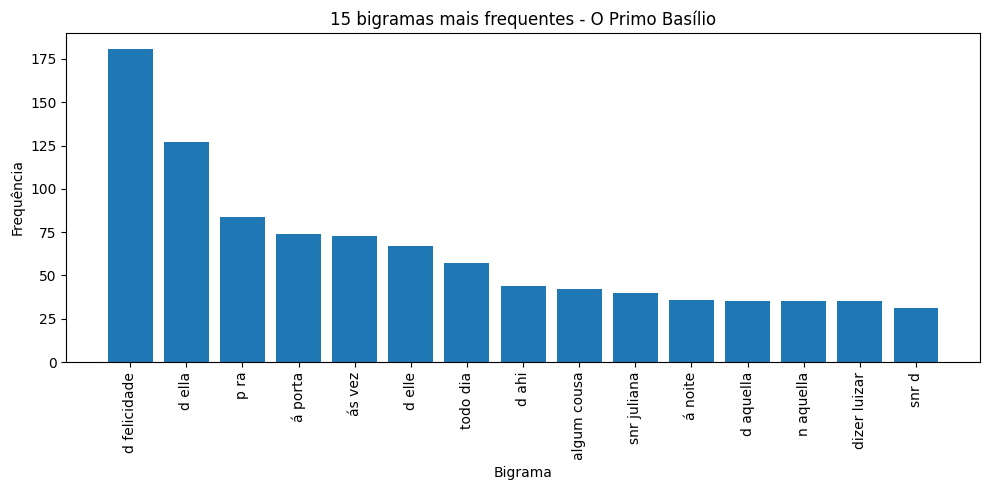

Seção 5 concluída.


In [ ]:
from wordcloud import WordCloud
from nltk.util import ngrams
import numpy as np
import re

for nome in obras:
    contador = Counter(lemmas[nome])

    print("\n", nome)
    print("Tokens únicos:", len(set(tokens_sem_stopwords[nome])))
    print("Lemas únicos:", len(set(lemmas[nome])))

    nuvem = WordCloud(width=900, height=450, background_color="white")
    nuvem.generate_from_frequencies(contador)

    plt.figure(figsize=(10, 5))
    plt.imshow(nuvem, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud - " + nome)
    plt.show()

def frases_com_tamanho(texto):
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    frases = re.split(r"[.!?]+", texto)
    tamanhos = []

    for frase in frases:
        qtd = len(word_tokenize(frase, language="portuguese"))
        if qtd > 0:
            tamanhos.append(qtd)

    return tamanhos

resumo_eda = []

for nome in obras:
    tamanhos = frases_com_tamanho(textos[nome])

    plt.figure(figsize=(8, 4))
    plt.hist(tamanhos, bins=20)
    plt.title("Distribuição do tamanho das frases - " + nome)
    plt.xlabel("Tokens por frase")
    plt.ylabel("Quantidade")
    plt.show()

    resumo_eda.append({
        "Obra": nome,
        "Total de tokens": len(tokens_sem_stopwords[nome]),
        "Lemas únicos": len(set(lemmas[nome])),
        "Frase mais longa": max(tamanhos) if tamanhos else 0,
        "Frase mais curta": min(tamanhos) if tamanhos else 0
    })

display(pd.DataFrame(resumo_eda))

for nome in obras:
    bigramas = Counter(ngrams(lemmas[nome], 2)).most_common(15)
    nomes = [" ".join(x[0]) for x in bigramas]
    valores = [x[1] for x in bigramas]

    plt.figure(figsize=(10, 5))
    plt.bar(nomes, valores)
    plt.xticks(rotation=90)
    plt.title("15 bigramas mais frequentes - " + nome)
    plt.xlabel("Bigrama")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

print("Seção 5 concluída.")

# Seção 6 — Chunking

Serão usadas duas formas de dividir o corpus: chunks fixos de 200 tokens com overlap de 50 e chunks por parágrafo com no mínimo 20 tokens.

In [ ]:
def criar_chunks_fixos(tokens, tamanho=200, overlap=50):
    chunks = []
    inicio = 0

    while inicio < len(tokens):
        fim = inicio + tamanho
        chunk = tokens[inicio:fim]

        if chunk:
            chunks.append(chunk)

        if fim >= len(tokens):
            break

        inicio += tamanho - overlap

    return chunks

def criar_chunks_paragrafos(texto, minimo=20):
    chunks = []

    for paragrafo in texto.split("\n"):
        palavras = paragrafo.split()

        if len(palavras) >= minimo:
            chunks.append(palavras)

    return chunks

chunks_fixos = {}
chunks_paragrafos = {}
metadados_chunks = []

for nome in obras:
    chunks_fixos[nome] = criar_chunks_fixos(lemmas[nome])
    chunks_paragrafos[nome] = criar_chunks_paragrafos(textos_limpos[nome])

    for i, chunk in enumerate(chunks_fixos[nome]):
        metadados_chunks.append({
            "obra": nome,
            "estrategia": "Fixo 200 / overlap 50",
            "chunk_id": i,
            "texto": " ".join(chunk)
        })

    for i, chunk in enumerate(chunks_paragrafos[nome]):
        metadados_chunks.append({
            "obra": nome,
            "estrategia": "Parágrafos >= 20",
            "chunk_id": i,
            "texto": " ".join(chunk)
        })

resumo_chunks = []

for nome in obras:
    for estrategia, dados in [
        ("Fixo 200 / overlap 50", chunks_fixos[nome]),
        ("Parágrafos >= 20", chunks_paragrafos[nome])
    ]:
        tamanhos = [len(x) for x in dados]

        resumo_chunks.append({
            "Obra": nome,
            "Estratégia": estrategia,
            "Total de chunks": len(dados),
            "Tamanho médio": round(np.mean(tamanhos), 2) if tamanhos else 0,
            "Menor": min(tamanhos) if tamanhos else 0,
            "Maior": max(tamanhos) if tamanhos else 0
        })

df_chunks = pd.DataFrame(resumo_chunks)
display(df_chunks)

print("Exemplos de chunks fixos:")
for chunk in chunks_fixos["Os Maias"][:3]:
    print(" ".join(chunk)[:800])
    print()

print("Exemplos de chunks por parágrafo:")
for chunk in chunks_paragrafos["Os Maias"][:3]:
    print(" ".join(chunk)[:800])
    print()

df_metadados = pd.DataFrame(metadados_chunks)
display(df_metadados.head())

,Obra,Estratégia,Total de chunks,Tamanho médio,Menor,Maior
0,Os Maias,Fixo 200 / overlap 50,855,199.98,186,200
1,Os Maias,Parágrafos >= 20,0,0.00,0,0
2,O Crime do Padre Amaro,Fixo 200 / overlap 50,553,199.83,105,200
3,O Crime do Padre Amaro,Parágrafos >= 20,0,0.00,0,0
4,O Primo Basílio,Fixo 200 / overlap 50,475,199.78,96,200
5,O Primo Basílio,Parágrafos >= 20,0,0.00,0,0


Exemplos de chunks fixos:
nota editor devido existência erro tipográfico texto tomar várias decisão quanto versão final caso dúvida grafia mantir acordo original final livro encontrar listar erro corrigir versão original obra compilação dois volume capítulo paginação independente publicar obra respeitar original compilámos ficheiro ambos parte rito farinha agosto porto typ j silva teixeira cancello velho eça queiroz episodio vida romantico livraria internacional ernesto chardron lugan genelioux successor todo direito reservar obra auctor crime padre amaro edição inteiramente refunder recomposta differente fórma acção edição primitivo grosso vol primo bazilio edição grosso vol mandarim edição vol reliquia grosso vol casa maia vir habitar lisboa outono conhecer visinhança rua s francisco paula todo bairro janella ver

sineta cruz topo assimilhar hia collegio jesuitas nome ramalhetir provinho certo d revestimento quadrado azulejo fazer painel logar heraldico escudo d arma nunca chegar col

,obra,estrategia,chunk_id,texto
0,Os Maias,Fixo 200 / overlap 50,0,nota editor devido existência erro tipográfico...
1,Os Maias,Fixo 200 / overlap 50,1,sineta cruz topo assimilhar hia collegio jesui...
2,Os Maias,Fixo 200 / overlap 50,2,x villaça responder tambem nobreza tempo sr d ...
3,Os Maias,Fixo 200 / overlap 50,3,venda tojeiro fôra realmente aconselhar villaç...
4,Os Maias,Fixo 200 / overlap 50,4,secco obra começar logo sob direcção d esteve ...


# Seção 7 — Geração de embeddings

Será usado o BERTimbau com mean pooling. Nesta etapa são gerados embeddings somente dos chunks fixos, como pedido no trabalho. O processamento será feito em lotes para diminuir o tempo de execução.

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Shape dos embeddings: (1883, 768)
Arquivo salvo e carregado.
Shape: (1883, 768)
Primeiros 10 valores do primeiro chunk:
[ 0.16637479 -0.31812814  0.5290313  -0.07835583  0.2741594   0.19807683
  0.16007037 -0.24274066  0.1412116   0.3602973 ]
Palavra: nota
Shape: (768,)
Primeiros 10 valores: [ 0.09156189 -0.20042303  0.5249432   0.15820155  0.07965064 -0.11093025
 -0.11098702 -0.2950901   0.30094203  0.54951984]
Palavra: editor
Shape: (768,)
Primeiros 10 valores: [ 0.15948229 -0.03569987  1.0128813   0.18386763  0.2036513  -0.12013242
  0.2632592  -0.27002677  0.43241656  0.76952904]
Palavra: produced
Shape: (768,)
Primeiros 10 valores: [ 0.23464248 -0.05674106  0.49702942  0.11852513  0.1948624  -0.21443659
  0.2869755  -0.20938255  0.2675026   0.66457677]
Palavra: by
Shape: (768,)
Primeiros 10 valores: [ 0.20194043 -0.16650915  0.89788616  0.07233636  0.30808002  0.09535442
  0.02931788 -0.24255571  0.25195575 -0.13925363]
Palavra: nota
Shape: (768,)
Primeiros 10 valores: [ 0.0915618

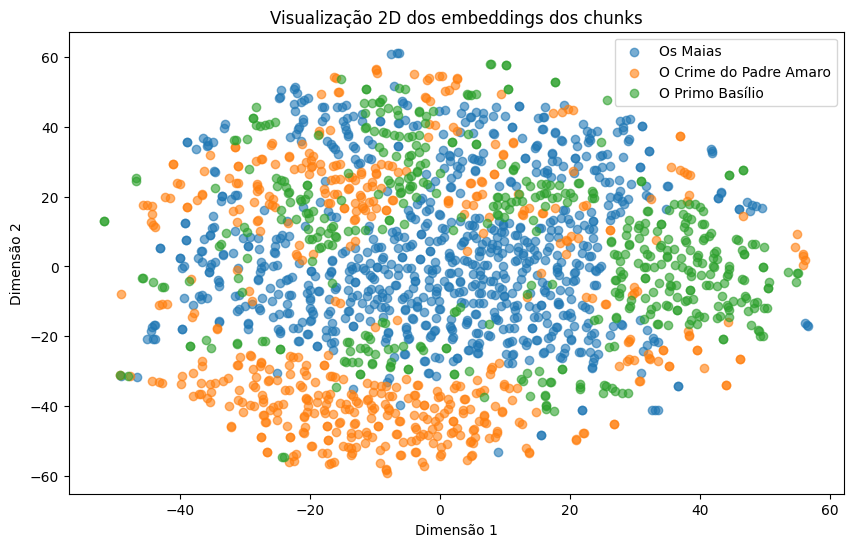

Seção 7 concluída.


In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

modelo_nome = "neuralmind/bert-base-portuguese-cased"

tokenizer_bert = AutoTokenizer.from_pretrained(modelo_nome)
modelo_bert = AutoModel.from_pretrained(modelo_nome)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_bert = modelo_bert.to(dispositivo)
modelo_bert.eval()

textos_chunks = []
origens_chunks = []

for nome in obras:
    for chunk in chunks_fixos[nome]:
        textos_chunks.append(" ".join(chunk))
        origens_chunks.append(nome)

def gerar_embeddings(textos, tamanho_lote=16):
    vetores = []

    for inicio in range(0, len(textos), tamanho_lote):
        lote = textos[inicio:inicio + tamanho_lote]

        entrada = tokenizer_bert(
            lote,
            padding=True,
            truncation=True,
            max_length=384,
            return_tensors="pt"
        )

        entrada = {chave: valor.to(dispositivo) for chave, valor in entrada.items()}

        with torch.no_grad():
            saida = modelo_bert(**entrada)

        mascara = entrada["attention_mask"].unsqueeze(-1)
        soma = (saida.last_hidden_state * mascara).sum(dim=1)
        total = mascara.sum(dim=1)
        vetor = soma / total

        vetores.append(vetor.cpu().numpy())

    return np.vstack(vetores)

embeddings = gerar_embeddings(textos_chunks)

print("Shape dos embeddings:", embeddings.shape)

np.save("embeddings_chunks.npy", embeddings)

embeddings_carregados = np.load("embeddings_chunks.npy")

print("Arquivo salvo e carregado.")
print("Shape:", embeddings_carregados.shape)
print("Primeiros 10 valores do primeiro chunk:")
print(embeddings_carregados[0][:10])

def obter_embedding_palavra(palavra):
    entrada = tokenizer_bert(
        palavra,
        return_tensors="pt",
        add_special_tokens=True
    )

    entrada = {chave: valor.to(dispositivo) for chave, valor in entrada.items()}

    with torch.no_grad():
        saida = modelo_bert(**entrada)

    ids = entrada["input_ids"][0]
    tokens = tokenizer_bert.convert_ids_to_tokens(ids)

    if len(tokens) <= 2:
        vetor = saida.last_hidden_state[0, 1:-1].mean(dim=0)
    else:
        vetor = saida.last_hidden_state[0, 1:-1].mean(dim=0)

    vetor = vetor.cpu().numpy()

    print("Palavra:", palavra)
    print("Shape:", vetor.shape)
    print("Primeiros 10 valores:", vetor[:10])

    return vetor

palavras_exemplo = []

for nome in obras:
    palavras_exemplo.extend(lemmas[nome][:2])

for palavra in palavras_exemplo[:5]:
    obter_embedding_palavra(palavra)

perplexidade = min(30, len(embeddings_carregados) - 1)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexidade,
    init="random",
    learning_rate="auto"
)

embeddings_2d = tsne.fit_transform(embeddings_carregados)

plt.figure(figsize=(10, 6))

for nome in obras:
    indices = [i for i, origem in enumerate(origens_chunks) if origem == nome]
    plt.scatter(
        embeddings_2d[indices, 0],
        embeddings_2d[indices, 1],
        label=nome,
        alpha=0.6
    )

plt.title("Visualização 2D dos embeddings dos chunks")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.legend()
plt.show()

print("Seção 7 concluída.")

# Seção 8 — Busca por similaridade semântica

A consulta será transformada em embedding com o mesmo BERTimbau usado na etapa anterior. Depois será calculada a similaridade de cosseno com os chunks.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def gerar_embedding_consulta(texto):
    entrada = tokenizer_bert(
        texto,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )

    entrada = {chave: valor.to(dispositivo) for chave, valor in entrada.items()}

    with torch.no_grad():
        saida = modelo_bert(**entrada)

    mascara = entrada["attention_mask"].unsqueeze(-1)
    soma = (saida.last_hidden_state * mascara).sum(dim=1)
    total = mascara.sum(dim=1)

    return (soma / total).cpu().numpy()

def buscar_similares(consulta, top_k=5):
    vetor_consulta = gerar_embedding_consulta(consulta)

    scores = cosine_similarity(
        vetor_consulta,
        embeddings_carregados
    )[0]

    indices = np.argsort(scores)[::-1][:top_k]

    resultados = []

    for indice in indices:
        resultados.append({
            "Texto do chunk": textos_chunks[indice],
            "Obra": origens_chunks[indice],
            "Score": round(float(scores[indice]), 4)
        })

    return resultados

consultas = [
    "uma família e sua vida em Lisboa",
    "a vida religiosa e o padre",
    "um relacionamento e uma casa em Lisboa"
]

for consulta in consultas:
    print("\nConsulta:", consulta)
    display(pd.DataFrame(buscar_similares(consulta, 5)))

print("Seção 8 concluída.")


Consulta: uma família e sua vida em Lisboa


,Texto do chunk,Obra,Score
0,sorr espelho enlevar brilho mocidade impacient...,Os Maias,0.4083
1,amaro imaginar padre natario emfim descobrirar...,O Crime do Padre Amaro,0.4022
2,vossê achar aquillo caro dizer outro negação i...,O Crime do Padre Amaro,0.4007
3,terrino louça japão carlos alegremente annunci...,Os Maias,0.3962
4,muito vez recolher maria inquietação pensar mi...,Os Maias,0.3939



Consulta: a vida religiosa e o padre


,Texto do chunk,Obra,Score
0,amaro imaginar padre natario emfim descobrirar...,O Crime do Padre Amaro,0.4483
1,então seguir idéa discursar contra preparação ...,O Crime do Padre Amaro,0.4354
2,sério natario indignar fallar sério forte pois...,O Crime do Padre Amaro,0.4292
3,peccado mortal discutir fallar leviandade d jo...,O Crime do Padre Amaro,0.4231
4,deferenciar questão politica estrangeiro obser...,O Crime do Padre Amaro,0.4215



Consulta: um relacionamento e uma casa em Lisboa


,Texto do chunk,Obra,Score
0,vossê achar aquillo caro dizer outro negação i...,O Crime do Padre Amaro,0.4458
1,muito vez recolher maria inquietação pensar mi...,Os Maias,0.4373
2,ainda agradecer ter vir murmurar carlos esquec...,Os Maias,0.4372
3,terrino louça japão carlos alegremente annunci...,Os Maias,0.4369
4,tambem encolher tamber ligeiramente hombro v e...,Os Maias,0.4347


Seção 8 concluída.


# Seção 9 — Predição da próxima palavra

Será treinado um modelo de linguagem com bigramas e trigramas usando o corpus lematizado combinado das três obras.

In [ ]:
from nltk.lm import Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline

corpus_lemmas = []

for nome in obras:
    corpus_lemmas.append(lemmas[nome])

treino_2, vocabulario_2 = padded_everygram_pipeline(2, corpus_lemmas)
modelo_2 = Laplace(2)
modelo_2.fit(treino_2, vocabulario_2)

treino_3, vocabulario_3 = padded_everygram_pipeline(3, corpus_lemmas)
modelo_3 = Laplace(3)
modelo_3.fit(treino_3, vocabulario_3)

vocabulario = list(modelo_3.vocab)

def preparar_entrada(texto):
    texto_limpo = limpar_texto(texto)
    tokens_entrada = word_tokenize(texto_limpo, language="portuguese")

    tokens_entrada = [
        palavra for palavra in tokens_entrada
        if palavra.isalpha() and palavra not in stop_words
    ]

    if not tokens_entrada:
        return []

    doc = nlp(" ".join(tokens_entrada))

    return [
        token.lemma_.lower()
        for token in doc
        if token.lemma_.isalpha()
    ]

def prever_proxima_palavra(texto_entrada, n=3, top_k=5):
    palavras = preparar_entrada(texto_entrada)

    if not palavras:
        return []

    modelo = modelo_3 if n == 3 else modelo_2

    contexto = palavras[-(n - 1):]
    resultados = []

    for palavra in vocabulario:
        if palavra in ["<s>", "</s>", "<UNK>"]:
            continue

        probabilidade = modelo.score(palavra, contexto)

        resultados.append({
            "Palavra": palavra,
            "Probabilidade": probabilidade
        })

    resultados = sorted(
        resultados,
        key=lambda x: x["Probabilidade"],
        reverse=True
    )

    return resultados[:top_k]

entradas_teste = [
    "Carlos e Maria",
    "o padre",
    "a casa",
    "a mulher",
    "a cidade"
]

for entrada in entradas_teste:
    print("\nEntrada:", entrada)
    display(pd.DataFrame(prever_proxima_palavra(entrada, 3, 5)))

print("Seção 9 concluída.")


Entrada: Carlos e Maria


,Palavra,Probabilidade
0,casa,0.000088
1,tamber,0.000088
2,passar,0.000088
3,ir,0.000088
4,achar,0.000088



Entrada: o padre


""



Entrada: a casa


...


Entrada: a mulher


""



Entrada: a cidade


""


Seção 9 concluída.


# Seção 10 — Interface interativa

A interface será feita com Gradio e terá três abas: exploração do corpus, embedding de palavras e predição da próxima palavra.

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

palavras_corpus = []

for nome in obras:
    palavras_corpus.extend(lemmas[nome][:150])

palavras_corpus = list(dict.fromkeys(palavras_corpus))[:300]

embeddings_palavras = gerar_embeddings(palavras_corpus, tamanho_lote=16)

df_interface = pd.DataFrame({
    "Título": list(obras.keys()),
    "Autor": [obras[nome]["autor"] for nome in obras],
    "Total de tokens": [len(tokens_sem_stopwords[nome]) for nome in obras],
    "Total de chunks": [len(chunks_fixos[nome]) for nome in obras]
})

def mostrar_wordcloud(nome):
    contador = Counter(lemmas[nome])

    nuvem = WordCloud(
        width=900,
        height=450,
        background_color="white"
    ).generate_from_frequencies(contador)

    figura, eixo = plt.subplots(figsize=(10, 5))
    eixo.imshow(nuvem, interpolation="bilinear")
    eixo.axis("off")
    eixo.set_title("WordCloud - " + nome)

    return figura

def mostrar_embedding(palavra):
    palavra = palavra.strip().lower()

    if palavra not in palavras_corpus:
        return None, "A palavra não está no vocabulário usado na interface."

    vetor = obter_embedding_palavra(palavra)

    figura, eixo = plt.subplots(figsize=(8, 6))
    valores = vetor[:20]

    eixo.barh(range(20), valores)
    eixo.set_yticks(range(20))
    eixo.set_yticklabels([str(i + 1) for i in range(20)])
    eixo.set_xlabel("Valor")
    eixo.set_title("Primeiros 20 valores do embedding")
    eixo.invert_yaxis()

    indice = palavras_corpus.index(palavra)
    scores = cosine_similarity(
        vetor.reshape(1, -1),
        embeddings_palavras
    )[0]

    melhores = np.argsort(scores)[::-1]

    similares = []

    for i in melhores:
        if palavras_corpus[i] != palavra:
            similares.append({
                "Palavra": palavras_corpus[i],
                "Similaridade": round(float(scores[i]), 4)
            })

        if len(similares) == 5:
            break

    texto_similares = "\n".join(
        [f"{x['Palavra']} — {x['Similaridade']}" for x in similares]
    )

    return figura, texto_similares

def mostrar_previsao(texto, n):
    n = int(n)
    resultados = prever_proxima_palavra(texto, n, 5)

    if not resultados:
        return None, "Digite uma palavra ou frase válida."

    palavras = [x["Palavra"] for x in resultados]
    valores = [x["Probabilidade"] for x in resultados]

    figura, eixo = plt.subplots(figsize=(8, 5))
    eixo.barh(palavras, valores)
    eixo.set_xlabel("Probabilidade")
    eixo.set_title("Top 5 próximas palavras")
    eixo.invert_yaxis()

    tabela = pd.DataFrame(resultados)

    return figura, tabela

with gr.Blocks(title="NLP - Eça de Queirós") as interface:
    gr.Markdown("# Processamento de Corpus Literário — Eça de Queirós")
    gr.Markdown("Os Maias, O Crime do Padre Amaro e O Primo Basílio")

    with gr.Tab("Exploração do Corpus"):
        gr.Dataframe(value=df_interface, interactive=False)
        escolha_obra = gr.Dropdown(
            choices=list(obras.keys()),
            value="Os Maias",
            label="Escolha a obra"
        )
        botao_nuvem = gr.Button("Mostrar WordCloud")
        imagem_nuvem = gr.Plot()
        botao_nuvem.click(
            mostrar_wordcloud,
            inputs=escolha_obra,
            outputs=imagem_nuvem
        )
        gr.Plot(value=plt.figure(figsize=(10, 6)))

    with gr.Tab("Embedding de Palavras"):
        palavra = gr.Textbox(label="Digite uma palavra")
        botao_embedding = gr.Button("Gerar embedding")
        grafico_embedding = gr.Plot()
        resultado_similares = gr.Textbox(label="5 palavras mais similares")
        botao_embedding.click(
            mostrar_embedding,
            inputs=palavra,
            outputs=[grafico_embedding, resultado_similares]
        )

    with gr.Tab("Predição da Próxima Palavra"):
        texto_entrada = gr.Textbox(label="Digite uma palavra ou frase")
        seletor_n = gr.Radio(
            choices=[2, 3],
            value=3,
            label="Modelo"
        )
        botao_previsao = gr.Button("Prever")
        grafico_previsao = gr.Plot()
        tabela_previsao = gr.Dataframe()
        botao_previsao.click(
            mostrar_previsao,
            inputs=[texto_entrada, seletor_n],
            outputs=[grafico_previsao, tabela_previsao]
        )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a168f172c8e33e8241.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
